Performing a comparison of the 10kb bed of reference coordinates and lifted.

In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

Comparing number of passing windows for chromosome X and the autosomes, lifted and reference assembly.

In [23]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC_MQ.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]
female_IDs = metadata_20x_filt.loc[metadata_20x_filt.gSEX == "F"].ID

count_sub = metadata_20x_filt.loc[~metadata_20x_filt.cov_chrX.isna()][["gSEX", "group", "species_genotyping", "species"]].value_counts().reset_index()
used_species = count_sub.loc[(count_sub.gSEX == "F") | ((count_sub.gSEX == "M") & (count_sub["count"] >= 2))].species_genotyping.unique()

In [24]:
df_l = []
for long_form in used_species:
    df_path = "../results/lifted_window_stats_20x_inds/{}_10kb_pi_windowed_annotated.txt".format(long_form)
    s_df = pd.read_csv(df_path, sep="\t")
    s_df["species"] = long_form
    df_l.append(s_df)
all_pi_df = pd.concat(df_l)

In [25]:
all_pi_df

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species
0,NC_060925.1,0,220.560738,47016,0.004691,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp
1,NC_060925.1,100000,4.757545,1214,0.003919,['OR4F21'],0,OR4F21,0.00938,Macaca_fascicularis_ssp
2,NC_060925.1,200000,212.822104,58860,0.003616,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp
3,NC_060925.1,300000,269.197770,63277,0.004254,['SAMD11' 'NOC2L' 'PLEKHN1' 'KLHL17'],0,SAMD11,0.17321,Macaca_fascicularis_ssp
4,NC_060925.1,400000,237.559592,81586,0.002912,['AGRN' 'PERM1' 'PLEKHN1' 'HES4' 'ISG15'],0,AGRN,0.34747,Macaca_fascicularis_ssp
...,...,...,...,...,...,...,...,...,...,...
28336,NC_060947.1,153800000,0.678400,60158,0.000011,['TMLHE'],0,TMLHE,0.94993,Semnopithecus_schistaceus_ssp
28337,NC_060947.1,153900000,0.258067,67648,0.000004,['SPRY3'],0,SPRY3,0.00867,Semnopithecus_schistaceus_ssp
28338,NC_060947.1,154000000,0.819000,48192,0.000017,NaN,0,NaN,0.00000,Semnopithecus_schistaceus_ssp
28339,NC_060947.1,154100000,1.534267,64030,0.000024,['VAMP7'],0,VAMP7,0.52682,Semnopithecus_schistaceus_ssp


Specific investigation into overall callability.

In [2]:
for bed_path in glob.glob("../results/window_stats_20x_inds/*_10kb_pi.bed"):
    long_form = bed_path.split("/")[-1].split("_10kb")[0]
    bed_df = pd.read_csv(bed_path, sep="\t", names=["chrom", "window_start", "window_end", "feature_name", "pi"])
    bed_df["chr_type"] = bed_df["feature_name"].str.split(":",expand=True)[0]
    bed_df["callable_frac"] = bed_df["feature_name"].str.split(":",expand=True)[1].astype(float)
    print(long_form, bed_df.callable_frac.mean())

Chlorocebus_pygerythrus_ssp 0.9283734457158923
Cebuella_pygmaea_ssp 0.9030860208408502
Pygathrix_nemaeus_ssp 0.8704107002894262
Macaca_cyclopis_ssp 0.9487567681582804
Saguinus_mystax_ssp 0.8140816907857086
Alouatta_juara_ssp 0.7915587695203703
Lepilemur_dorsalis_ssp 0.5847897241370876
Cercopithecus_mona_ssp 0.9524683597018152
Microcebus_jonahi_ssp 0.7909292130114569
Macaca_sylvanus_ssp 0.9132915443541724
Chlorocebus_dryas_ssp 0.8985333994757343
Trachypithecus_germaini_ssp 0.9277920986929062
Cercocebus_chrysogaster_ssp 0.8954961610827223
Eulemur_collaris_ssp 0.9407738150257713
Pan_paniscus_ssp 0.8519756130304168
Daubentonia_madagascariensis_ssp 0.9905407861514366
Plecturocebus_bernhardi_ssp 0.9562908380098234
Chiropotes_israelita_ssp 0.9071620992018385
Ateles_geoffroyi_ssp 0.8998155290855959
Trachypithecus_phayrei_ssp 0.9360563327005051
Eulemur_rubriventer_ssp 0.9537361028700163
Semnopithecus_entellus_ssp 0.9248975705775518
Leontopithecus_rosalia_ssp 0.9845161403824276
Saimiri_oerstedii

Trachypithecus_pileatus_ssp 0.9005597204510608
Symphalangus_syndactylus_ssp 0.8329028624295257
Saguinus_inustus_ssp 0.8114246150223069
Callithrix_kuhlii_ssp 0.8759792531342643
Rhinopithecus_avunculus_ssp 0.7334567435025487
Presbytis_comata_ssp 0.8402570813950727
Cebus_unicolor_ssp 0.9418696308186197
Pithecia_chrysocephala_ssp 0.9720765356127256
Plecturocebus_cupreus_ssp 0.9686354675628074
Trachypithecus_cristatus_ssp 0.9239260892303833
Gorilla_beringei_ssp 0.797584485933445
Pygathrix_nigripes_ssp 0.8598712567434601
Trachypithecus_obscurus_ssp 0.9288014951463268
Trachypithecus_vetulus_ssp 0.9229949891816763
Cheracebus_lucifer_ssp 0.8774230687881378
Semnopithecus_schistaceus_ssp 0.9161023291636218
Trachypithecus_johnii_ssp 0.9218158091185236
Aotus_griseimembra_ssp 0.9296040020697812
Trachypithecus_francoisi_ssp 0.9612522830093384
Varecia_variegata_ssp 0.980294385484607
Theropithecus_gelada_ssp 0.965682894398767
Carlito_syrichta_ssp 0.8338228695360136
Cacajao_melanocephalus_ssp 0.90833266

Surprising that macaca is slightly worse, but this is also very depdendant on depth and number of samples used.

In [3]:
bed_path = "../results/window_stats_20x_inds/{}_10kb_pi.bed".format("Arctocebus_calabarensis_ssp")
long_form = bed_path.split("/")[-1].split("_10kb")[0]
bed_df = pd.read_csv(bed_path, sep="\t", names=["chrom", "window_start", "window_end", "feature_name", "pi"])
bed_df["chr_type"] = bed_df["feature_name"].str.split(":",expand=True)[0]
bed_df["callable_frac"] = bed_df["feature_name"].str.split(":",expand=True)[1].astype(float)

<Axes: xlabel='callable_frac', ylabel='Count'>

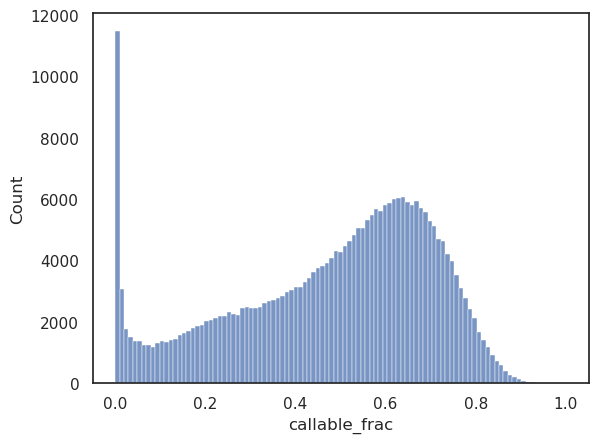

In [4]:
sns.histplot(bed_df, x="callable_frac")

In [5]:
pd.cut(bed_df.callable_frac, 10)

0         (-0.001, 0.1]
1            (0.2, 0.3]
2            (0.4, 0.5]
3            (0.7, 0.8]
4            (0.6, 0.7]
              ...      
285778       (0.1, 0.2]
285779    (-0.001, 0.1]
285780    (-0.001, 0.1]
285781    (-0.001, 0.1]
285782    (-0.001, 0.1]
Name: callable_frac, Length: 285783, dtype: category
Categories (10, interval[float64, right]): [(-0.001, 0.1] < (0.1, 0.2] < (0.2, 0.3] < (0.3, 0.4] ... (0.6, 0.7] < (0.7, 0.8] < (0.8, 0.9] < (0.9, 1.0]]

<Axes: xlabel='cut', ylabel='pi'>

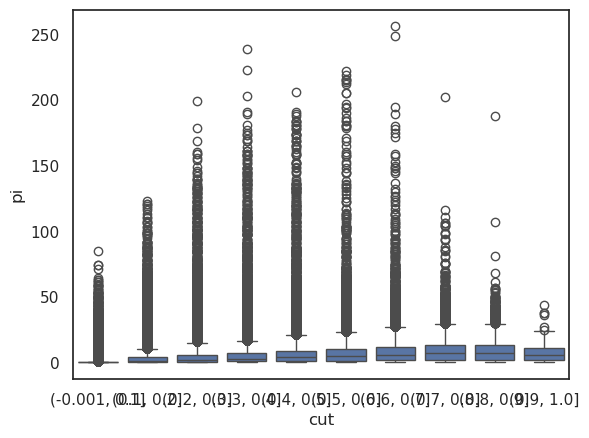

In [6]:
bed_df["cut"] = pd.cut(bed_df.callable_frac, 10)
sns.boxplot(bed_df, x="cut", y="pi")

/tmp/46063259/ipykernel_3562709/2912367716.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trimmed_adj["cut"] = pd.cut(trimmed_adj.callable_frac, 10)
/tmp/46063259/ipykernel_3562709/2912367716.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trimmed_adj["pi_adj"] = trimmed_adj.pi/trimmed_adj.callable_frac


<Axes: xlabel='cut', ylabel='pi_adj'>

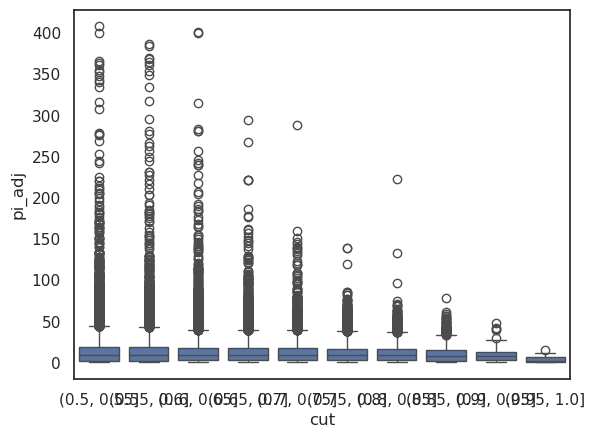

In [7]:
trimmed_adj = bed_df.loc[bed_df.callable_frac >= 0.5]
trimmed_adj["cut"] = pd.cut(trimmed_adj.callable_frac, 10)
trimmed_adj["pi_adj"] = trimmed_adj.pi/trimmed_adj.callable_frac
sns.boxplot(trimmed_adj, x="cut", y="pi_adj")

In [8]:
trimmed_adj.groupby(["cut"])[["pi"]].mean()

/tmp/46063259/ipykernel_3562709/2317724764.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trimmed_adj.groupby(["cut"])[["pi"]].mean()


,pi
cut,
"(0.5, 0.55]",7.240364
"(0.55, 0.6]",7.569295
"(0.6, 0.65]",7.924725
"(0.65, 0.7]",8.246969
"(0.7, 0.75]",8.718130
"(0.75, 0.8]",8.996078
"(0.8, 0.85]",9.080733
"(0.85, 0.9]",9.040581
"(0.9, 0.95]",8.245283


In [9]:
trimmed_adj.groupby(["cut"])[["pi_adj"]].mean()

/tmp/46063259/ipykernel_3562709/3183431587.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trimmed_adj.groupby(["cut"])[["pi_adj"]].mean()


,pi_adj
cut,
"(0.5, 0.55]",13.779999
"(0.55, 0.6]",13.157089
"(0.6, 0.65]",12.683138
"(0.65, 0.7]",12.228914
"(0.7, 0.75]",12.049502
"(0.75, 0.8]",11.652463
"(0.8, 0.85]",11.066556
"(0.85, 0.9]",10.424695
"(0.9, 0.95]",9.007446


In [10]:
bed_df.loc[(bed_df.callable_frac >= 0.75)]["pi"].mean()

9.014262302343093

Checking the lifted version of the bed - much more fragmented.

In [11]:
bed_path = "../results/lifted_window_stats_20x_inds/{}_10kb_pi.bed".format("Arctocebus_calabarensis_ssp")
long_form = bed_path.split("/")[-1].split("_10kb")[0]
bed_df = pd.read_csv(bed_path, sep="\t", names=["chrom", "window_start", "window_end", "feature_name", "pi"])
bed_df["chr_type"] = bed_df["feature_name"].str.split(":",expand=True)[0]
bed_df["callable_frac"] = bed_df["feature_name"].str.split(":",expand=True)[1].astype(float)

In [12]:
bed_df["window_size"] = bed_df.window_end-bed_df.window_start

In [13]:
bed_df.loc[bed_df.window_size >= 5000]

,chrom,window_start,window_end,feature_name,pi,chr_type,callable_frac,window_size
759336,NC_060928.1,128618684,128623904,aut:0.8121,0.0,aut,0.8121,5220
15178456,NC_060926.1,179013635,179018660,aut:0.9779,0.0,aut,0.9779,5025
15178647,NC_060926.1,179042069,179048431,aut:0.9682,2.0,aut,0.9682,6362
15178648,NC_060926.1,179048431,179058431,aut:0.9997,0.0,aut,0.9997,10000
29038130,NC_060937.1,22537821,22545729,aut:0.9669,6.0,aut,0.9669,7908


In [14]:
# Number of bases from chrX lifted to human coordinates and chrX
bed_df.loc[(bed_df.chr_type == "chrX") & (bed_df.chrom == "NC_060947.1")].window_size.sum()

53145110

In [15]:
# Number of bases from chrX lifted to human coordinates and not chrX
bed_df.loc[(bed_df.chr_type == "chrX") & (bed_df.chrom != "NC_060947.1")].window_size.sum()

2183350

In [16]:
2183350/53145110

0.04108280140919832